# Naive-Bayes Classifier

In [10]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.model_selection import train_test_split

In [18]:
df = pd.read_csv('/Users/nourbenammar/Desktop/Esprit_project/cleaned_learning_outcomes.csv')

# removes all punctuations and change to lower case
df['text'] = df['text'].str.replace(r'[^\w\s]+', '', regex=True)
df['text'] = df['text'].str.lower()

# Blooms taxonomy categories
categories = ['Remember', 'Understand', 'Apply', 'Analyze', 'Evaluate', 'Create']

In [19]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [22]:
def augment_sentence(sentence, aug):
    """""""""
    Constructs a new sentence via text augmentation.

    Input:
        - sentence:     A string of text
        - aug:          An augmentation object defined by the nlpaug library

    Output:
        - A string of text that been augmented
    """""""""
    return aug.augment(sentence)[0]
    

def augment_data(df, aug, target_count):
    """
    Takes a pandas DataFrame and augments its text data to a target count
    
    Input:
        - df:            A pandas DataFrame
        - aug:           Augmentation object defined by the nlpaug library.
        - target_count:  Integer representing the number of times to augment text to match count
    Output:
        - df:            Copy of the same pandas DataFrame with augmented data 
                         appended to it and with rows randomly shuffled.
    """
    for category in tqdm(df['label'].unique()):
        # gets the existing data
        existing_text = df[df['label']==category]

        # number of extra augmented data to be generated
        num_to_gen = target_count - len(existing_text)

        # do not need to generate more as target count has been obtained
        if num_to_gen <= 0:
            continue

        # randomly select required number of text from current sample
        data_to_aug = existing_text.sample(n=num_to_gen, replace=True)

        # augment the data
        data_to_aug['text'] = data_to_aug['text'].apply(augment_sentence, aug=aug)

        # Use pd.concat instead of append
        df = pd.concat([df, data_to_aug], ignore_index=True)
    
    # shuffle samples and return
    return df.sample(frac=1, random_state=0)

In [ ]:
import nlpaug.augmenter.word as nlpaw
from tqdm import tqdm

# Use wordnet to replace words with synonyms
aug = nlpaw.SynonymAug(aug_src='wordnet',aug_max=3)

# get label with the highest count from training set
max_count = max(list(train['label'].value_counts()))

# augment all training datasets to max_count
balanced__train = augment_data(train, aug, target_count=max_count)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 6/6 [00:03<00:00,  1.76it/s]


In [24]:
print("Before augmentation:")
print(train['label'].value_counts())

balanced_train = augment_data(train, aug, target_count=max_count)

print("\nAfter augmentation:")
print(balanced_train['label'].value_counts())

Before augmentation:
label
1    4040
2    4035
5    2365
4    1978
3    1876
0     724
Name: count, dtype: int64


100%|██████████| 6/6 [00:03<00:00,  1.78it/s]


After augmentation:
label
0    4040
1    4040
3    4040
2    4040
5    4040
4    4040
Name: count, dtype: int64


##  Model Building and Analysis

In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

def generate_model(model):
    # Fit text to labels
    model.fit(balanced_train.text, balanced_train.label)

    # Generate blooms label on test set
    labels = model.predict(test.text)

    # Heatmap of model
    mat = confusion_matrix(test.label, labels)
    sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False
                , xticklabels=categories
                , yticklabels=categories)

    plt.xlabel('true label')
    plt.ylabel('predicted label')

    print(classification_report(test.label, labels))
    # Model Accuracy, how often is the classifier correct?

    acc = accuracy_score(test.label, labels)
    print("Accuracy:", acc)

              precision    recall  f1-score   support

           0       0.49      0.58      0.53       162
           1       0.76      0.77      0.76      1039
           2       0.72      0.73      0.72      1039
           3       0.73      0.69      0.71       435
           4       0.75      0.70      0.72       490
           5       0.73      0.73      0.73       590

    accuracy                           0.72      3755
   macro avg       0.70      0.70      0.70      3755
weighted avg       0.73      0.72      0.73      3755

Accuracy: 0.7249001331557923


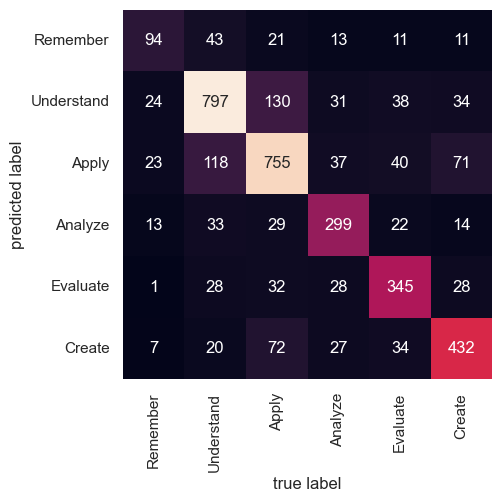

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from imblearn.over_sampling import SMOTE

# Creating model based on Multinomial Naive Bayes with TfidfVectorizer and SMOTE for oversampling
model_NB = Pipeline([
   ('vect', TfidfVectorizer()),
   ('smote', SMOTE(random_state=12)),
   ('mnb', MultinomialNB())
])

generate_model(model_NB)